<a href="https://colab.research.google.com/github/nuralfiyanti/PCVK_Ganjil2026/blob/main/Week07_17.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Nama  : Nur Alfiyanti

NIM   : 244107020055

Kelas : TI-3E

Modul 6 Filter Spasial Low Pass Filter, High Pass Filter, Point
Detection, Line Detection, Edge Detection

## **D. Praktikum Filter**

**1. Buat fungsi konvolusi menggunakan algoritma yang telah dijelaskan pada Bagian C, tanpa
menggunakan library atau metode konvolusi dari OpenCV.***

**2. Berikut merupakan langkah-langkah yang dapat dilakukan:**

**a. Buat notebook baru pada google colab, dan beri nama Week7.ipynb. Simpan Salinan
pada akun github seperti pada modul sebelumnya.**

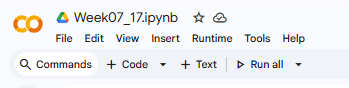

**b. Akses file yang terdapat pada drive dan import beberapa library yang dibutuhkan**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
import math
from google.colab.patches import cv2_imshow
from PIL import Image as im
BASE = '/content/drive/MyDrive/PCVK'

**c. Buatlah fungsi konvolusi. Catatan: parameter yang digunakan boleh dimodifikasi.
Misal, hanya menggunakan parameter image dan kernel saja, atau image, kernel, dan padding.**

**Konvolusi tanpa Library**



In [ ]:
def convolution2d(image, kernel, stride=1, padding=1):
    img = image.astype(np.float32)
    kH, kW = kernel.shape
    H, W = img.shape

    padded = np.zeros((H + 2*padding, W + 2*padding), dtype=np.float32)
    padded[padding:padding+H, padding:padding+W] = img

    out_H = (H + 2*padding - kH) // stride + 1
    out_W = (W + 2*padding - kW) // stride + 1
    output = np.zeros((out_H, out_W), dtype=np.float32)

    for i in range(out_H):
        for j in range(out_W):
            y = i * stride
            x = j * stride
            region = padded[y:y+kH, x:x+kW]
            output[i, j] = np.sum(region * kernel)

    return np.clip(output, 0, 255).astype(np.uint8)

**d. Load citra yang akan diproses dan ubah menjadi citra keabuan**

In [ ]:
img = cv.imread(BASE + '/mandrill.tiff')
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)


**e. Tentukan kernel yang akan digunakan, contohnya kernel untuk filter sharpening
sebagai berikut:**

In [ ]:
kernel_sharpen = np.array([[ 0, -1,  0],
                           [-1,  5, -1],
                           [ 0, -1,  0]])

**f. Memanggil fungsi konvolusi yang telah dibuat sebelumnya, dan menampilkan hasil
konvolusinya:**

Selisih maks vs cv.filter2D: 0


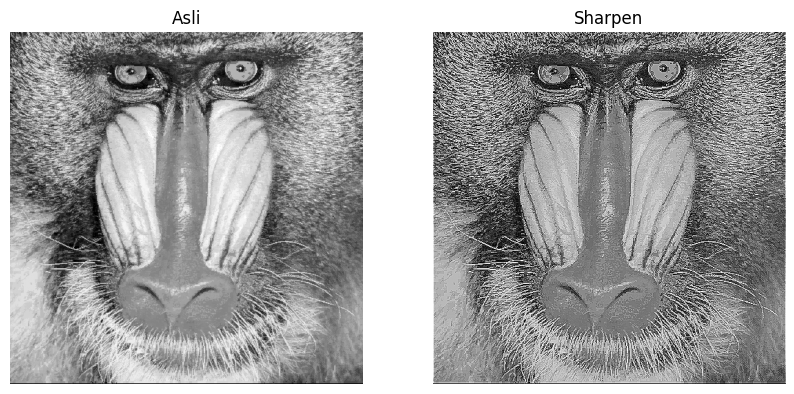

In [ ]:
hasil_sharpen = convolution2d(img_gray, kernel_sharpen, 1, 1)

# verifikasi terhadap OpenCV
ref = cv.filter2D(img_gray, -1, kernel_sharpen, borderType=cv.BORDER_CONSTANT)
print('Selisih maks vs cv.filter2D:', np.abs(hasil_sharpen.astype(int) - ref.astype(int)).max())

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(img_gray, cmap='gray'); ax[0].set_title('Asli'); ax[0].axis('off')
ax[1].imshow(hasil_sharpen, cmap='gray'); ax[1].set_title('Sharpen'); ax[1].axis('off')
plt.show()

**Buat Image Filter untuk Average filter, low pass filter, high pass filter, dan beberapa filter
berikut:**

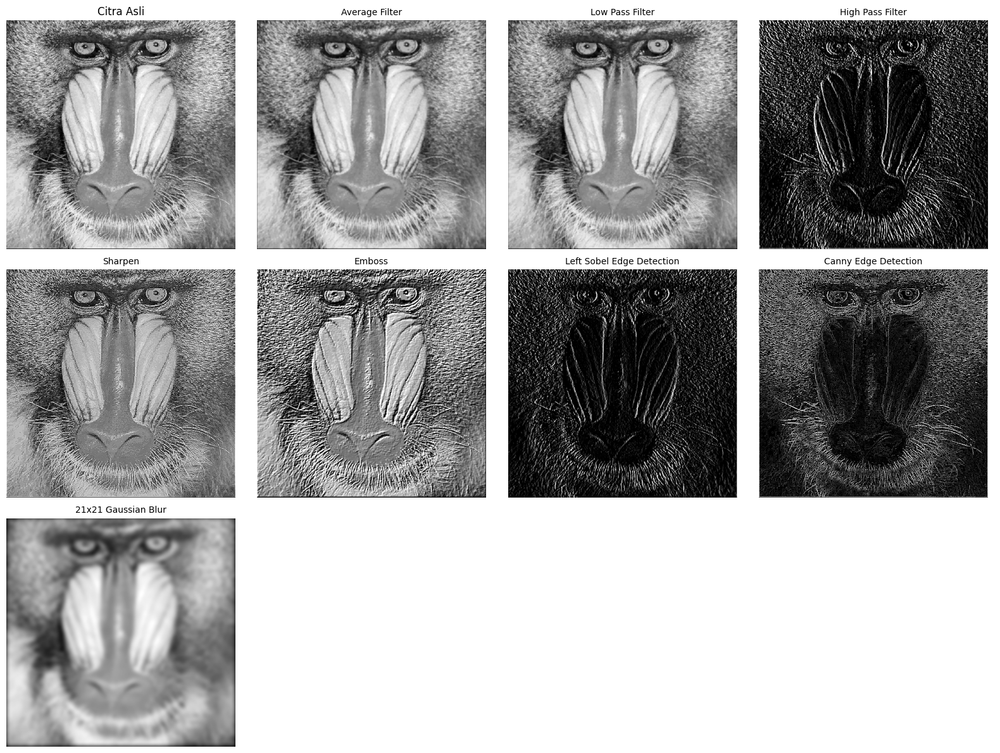

In [ ]:
# Definisi kernel
kernel_average = np.ones((3,3), dtype=np.float32) / 9
kernel_lpf = np.array([[1,1,1],[1,4,1],[1,1,1]], dtype=np.float32) / 12
kernel_hpf = np.array([[-1,0,1],[-1,0,3],[-3,0,1]], dtype=np.float32)
kernel_sharpen = np.array([[0,-1,0],[-1,5,-1],[0,-1,0]], dtype=np.float32)
kernel_emboss = np.array([[-2,-1,0],[-1,1,1],[0,1,2]], dtype=np.float32)
kernel_sobel_left = np.array([[1,0,-1],[2,0,-2],[1,0,-1]], dtype=np.float32)
kernel_canny = np.array([[-1,-1,-1],[-1,8,-1],[-1,-1,-1]], dtype=np.float32)

kernel_size = 21
sigma = math.sqrt(kernel_size)
g1 = cv.getGaussianKernel(kernel_size, sigma)
gauss_kernel_21 = g1 @ g1.T

# Daftar filter
daftar_filter = [
    ('Average Filter', kernel_average),
    ('Low Pass Filter', kernel_lpf),
    ('High Pass Filter', kernel_hpf),
    ('Sharpen', kernel_sharpen),
    ('Emboss', kernel_emboss),
    ('Left Sobel Edge Detection', kernel_sobel_left),
    ('Canny Edge Detection', kernel_canny),
    ('21x21 Gaussian Blur', gauss_kernel_21),
]

# Tampilkan dalam satu grid
ncols = 4
nrows = math.ceil((len(daftar_filter) + 1) / ncols)
fig, ax = plt.subplots(nrows, ncols, figsize=(4*ncols, 4*nrows))
ax = ax.reshape(-1)
for a in ax:
    a.axis('off')

ax[0].imshow(img_gray, cmap='gray')
ax[0].set_title('Citra Asli')

for i, (nama, kernel) in enumerate(daftar_filter, start=1):
    pad = kernel.shape[0] // 2
    hasil = convolution2d(img_gray, kernel, 1, pad)
    ax[i].imshow(hasil, cmap='gray')
    ax[i].set_title(nama, fontsize=10)

plt.tight_layout()
plt.show()

## **E. Filter Library dan Filter Modern**

Pada beberapa percobaan berikut ini kita akan melihat beberapa filter menggunakan library, filter
modern yang digunakan pada CNN, filter modern dengan kombinasi beberapa filter tradisional (tanpa
Deep Learning).

 **Percobaan 1:**

 Pada percobaan 1 ini, kita akan membuat Filter Gaussian, Sharpen, dan Canny menggunakan library
filter2d dari OpenCV. Filter ini akan kita terapkan pada Image RGB. Pada bagian awal kode terdapat
fungsi show_side_by_side yang digunakan untuk menampilkan gambar secara berdampingan.

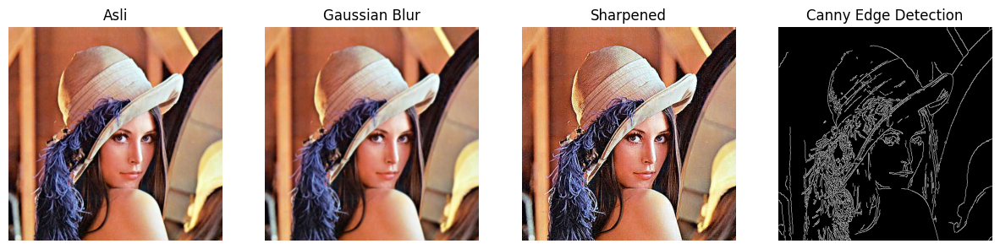

In [ ]:
# Fungsi tampil berdampingan
def show_side_by_side(images, titles, figsize=(15,5)):
    plt.figure(figsize=figsize)
    for i, (img, title) in enumerate(zip(images, titles)):
        if len(img.shape) == 2:  # grayscale
            plt.subplot(1, len(images), i+1)
            plt.imshow(img, cmap="gray")
        else:  # color
            plt.subplot(1, len(images), i+1)
            plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
        plt.title(title)
        plt.axis("off")
    plt.show()

img = cv.imread(BASE + '/lena.jpg.jpeg')
img_gray = cv.cvtColor(img,cv.COLOR_BGR2GRAY)

blur = cv.GaussianBlur(img, (7,7), 1)
edges = cv.Canny(cv.cvtColor(img, cv.COLOR_BGR2GRAY), 100, 200)
sharpen_kernel = np.array([[0,-1,0],[-1,5,-1],[0,-1,0]])
sharpened = cv.filter2D(img, -1, sharpen_kernel)
show_side_by_side([img, blur, sharpened, edges],
                   ["Asli", "Gaussian Blur", "Sharpened", "Canny Edge Detection"])

**Percobaan 2:**

Pada percobaan 2 berikut ini akan dilakukan filtering modern dari Library OpenCV. Dua filter yang akan
digunakan adalah Bilateral Filtering dan Guided Filter. **Bilateral filtering** adalah sebuah metode
penyaringan non-linear yang banyak digunakan untuk menghaluskan citra sekaligus tetap
mempertahankan ketajaman tepi. Berbeda dengan Gaussian blur biasa yang hanya memperhitungkan
jarak spasial antar piksel, bilateral filter juga mempertimbangkan perbedaan intensitas warna. Dengan
cara ini, piksel-piksel yang letaknya dekat dan memiliki warna mirip dengan pusat jendela akan
mendapat bobot lebih besar dalam perhitungan, sedangkan piksel dengan perbedaan warna kontras
(misalnya di sisi tepi) akan tereduksi pengaruhnya. Akibatnya, citra menjadi lebih halus pada area
datar, namun garis batas dan detail penting tetap terjaga. Meskipun menghasilkan kualitas yang baik,
bilateral filter tergolong lambat karena perhitungan bobot yang cukup kompleks. Dalam praktiknya,
filter ini banyak dipakai untuk keperluan seperti perbaikan kualitas foto, pengurangan noise, maupun
sebagai dasar dari efek beauty filter untuk melembutkan tekstur kulit tanpa mengaburkan kontur
wajah.

**Guided filtering** merupakan teknik yang lebih modern dan efisien. Filter ini didasarkan pada asumsi
bahwa, dalam sebuah jendela lokal, hasil penyaringan dapat direpresentasikan sebagai fungsi linear
dari citra pemandu (guide image). Artinya, setiap piksel keluaran dihitung dengan mempertimbangkan
hubungan linier antara nilai piksel di citra masukan dengan nilai piksel pada citra pemandu. Jika citra
masukan dan citra pemandu sama, guided filter akan berperan mirip bilateral filter namun dengan
perhitungan yang jauh lebih cepat dan hasil yang lebih halus. Keunggulan lainnya, guided filter bisa
menggunakan citra yang berbeda sebagai pemandu sehingga mampu mengarahkan proses filtering
sesuai kebutuhan. Berkat sifat ini, guided filter sering dipakai dalam berbagai aplikasi lanjutan seperti
HDR tone mapping, peningkatan detail, image matting, feathering, serta pemurnian depth map pada
sistem stereo vision. Secara umum, guided filter menawarkan keseimbangan antara preservasi tepi
yang baik, kualitas visual yang halus, dan efisiensi komputasi, sehingga dianggap sebagai
penyempurnaan dari pendekatan bilateral filtering

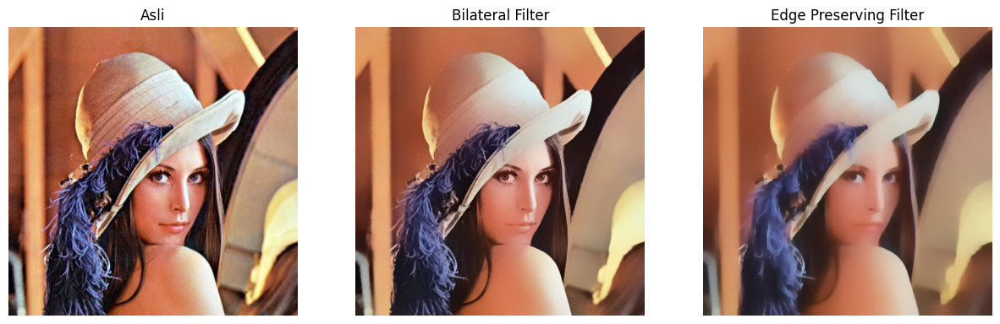

In [ ]:
# Filter Modern dari OpenCV
# Bilateral Filter (edge-preserving)
bilateral = cv.bilateralFilter(img, 50, 100, 100)

# Edge Preserving Filter (alternatif Guided Filter)
edge_preserve = cv.edgePreservingFilter(img, flags=1, sigma_s=100, sigma_r=0.9)

show_side_by_side(
    [img, bilateral, edge_preserve],
    ["Asli", "Bilateral Filter", "Edge Preserving Filter"]
)

**Percobaan 3:**

Percobaan kali ini akan mencoba melihat proses Filtering pada CNN (bagian Feature Map), lakukan
running code beberapa kali dan perhatikan hasil outputnya. Apa yang dapat kamu simpulkan dari hasil
keluaran tersebut.

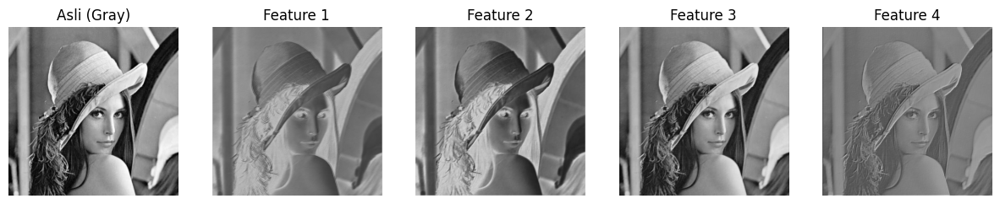

In [ ]:
# Filter Feature Map yang digunakan pada CNN
# Lakukan running code bagian ini beberapa kali dan perhatikan hasilnya

import torch
import torch.nn as nn

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 4, kernel_size=3, stride=1, padding=1)

    def forward(self, x):
        return self.conv1(x)

model = SimpleCNN()

# Ubah gambar ke tensor
img_tensor = torch.tensor(img_gray, dtype=torch.float32).unsqueeze(0).unsqueeze(0) / 255.0

# Hasil CNN
with torch.no_grad():
    features = model(img_tensor)

# Visualisasi feature maps
feature_maps = [(features[0, i].numpy()) for i in range(features.shape[1])]
show_side_by_side(
    [img_gray] + feature_maps,
    ["Asli (Gray)"] + [f"Feature {i+1}" for i in range(len(feature_maps))]
)

**Percobaan 4:**

Percobaan kali ini akan melakukan efek Beauty dan Vintage yang biasanya digunakan pada Aplikasi
popular saat ini. Filter yang digunakan merupakan kombinasi dari filter tradisional. Perlu diketahui
untuk filter aplikasi popular bisa jadi tidak menggunakan metode yang sama. Pada Aplikasi popular
bisa jadi menggunakan model GenAI dengan data Training untuk memberikan hasil yang lebih akurat.

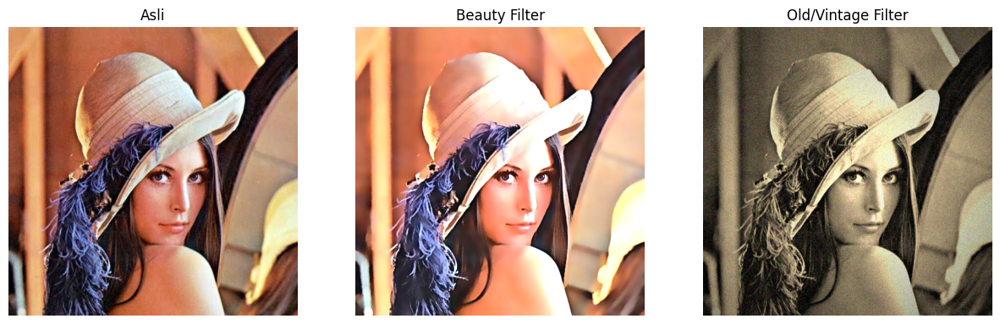

In [ ]:
# =====================
# 1. Beauty Filter
# =====================

# Step 1: Smoothing kulit dengan bilateral filter
smooth = cv.bilateralFilter(img, d=15, sigmaColor=75, sigmaSpace=75)

# Step 2: Unsharp masking (pertajam mata/bibir)
gaussian = cv.GaussianBlur(smooth, (0, 0), 3)
sharpened = cv.addWeighted(smooth, 1.5, gaussian, -0.5, 0)

# Step 3: Brightness dan contrast
alpha = 1.2  # contrast
beta = 15    # brightness
beauty = cv.convertScaleAbs(sharpened, alpha=alpha, beta=beta)


# =====================
# 2. Old/Vintage Filter
# =====================

# Step 1: Sepia tone
sepia_kernel = np.array([
    [0.272, 0.534, 0.131],
    [0.349, 0.686, 0.168],
    [0.393, 0.769, 0.189]
])

sepia = cv.transform(img, sepia_kernel)
sepia = np.clip(sepia, 0, 255).astype(np.uint8)

# Step 2: Vignette
rows, cols = img.shape[:2]
kernel_x = cv.getGaussianKernel(cols, cols * 0.6)
kernel_y = cv.getGaussianKernel(rows, rows * 0.6)
kernel = kernel_y * kernel_x.T
mask = kernel / kernel.max()

vignette = np.copy(sepia)
for i in range(3):
    vignette[:, :, i] = vignette[:, :, i] * mask

# Step 3: Noise/Grain
noise = np.random.normal(0, 15, vignette.shape).astype(np.int16)
old_img = np.clip(vignette.astype(np.int16) + noise, 0, 255).astype(np.uint8)

show_side_by_side([img, beauty, old_img], ["Asli", "Beauty Filter", "Old/Vintage Filter"])


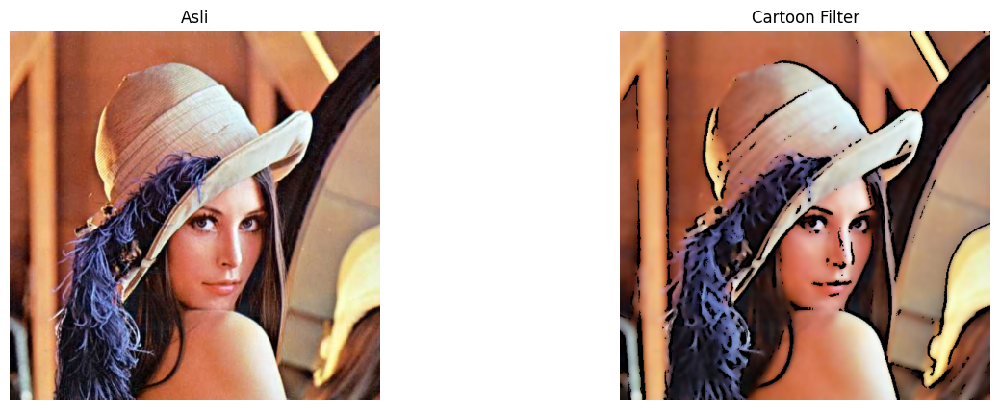

In [ ]:
# Filter Anime / Cartoon

# Step 1: Edge detection (pakai median blur dulu agar gambar menjadi lebih halus)
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
gray_blur = cv.medianBlur(gray, 7)
edges = cv.adaptiveThreshold(
    gray_blur,
    255,
    cv.ADAPTIVE_THRESH_MEAN_C,
    cv.THRESH_BINARY,
    9,
    9
)

# Step 2: Bilateral filter untuk smoothing warna
color = cv.bilateralFilter(img, d=9, sigmaColor=200, sigmaSpace=200)

# Step 3: Gabungkan (cartoonize)
cartoon = cv.bitwise_and(color, color, mask=edges)

# Tampilkan
show_side_by_side([img, cartoon], ["Asli", "Cartoon Filter"])

**Percobaan 6:**

Pada Percobaan 6 akan ditunjukkan contoh Filter Malam.

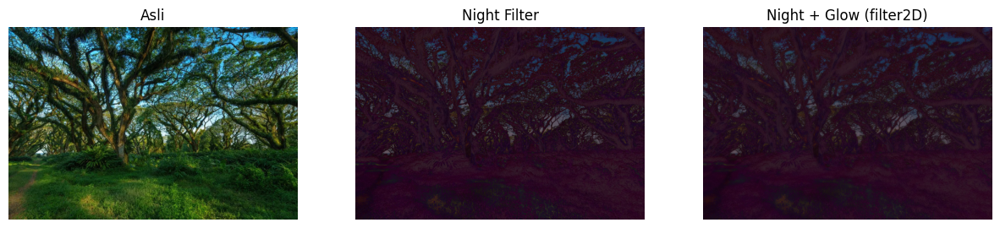

In [ ]:
# Night Filter
img = cv.imread("/content/drive/MyDrive/PCVK/djawatan.jpg")
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# Step 1: Gelapkan (contrast turun, brightness negatif)
night = cv.convertScaleAbs(img, alpha=0.6, beta=-40)

# Step 2: Tambah bias biru
blue_tint = np.full_like(night, (50, 0, 100))  # BGR
night = cv.addWeighted(night, 0.8, blue_tint, 0.2, 0)

# Step 3: Efek glow di area terang dengan filter2D (blur kernel)
kernel = np.ones((15, 15), np.float32) / 225
glow = cv.filter2D(night, -1, kernel)

# Kombinasikan asli + glow
night_glow = cv.addWeighted(night, 0.7, glow, 0.3, 0)

show_side_by_side(
    [img, night, night_glow],
    ["Asli", "Night Filter", "Night + Glow (filter2D)"]
)

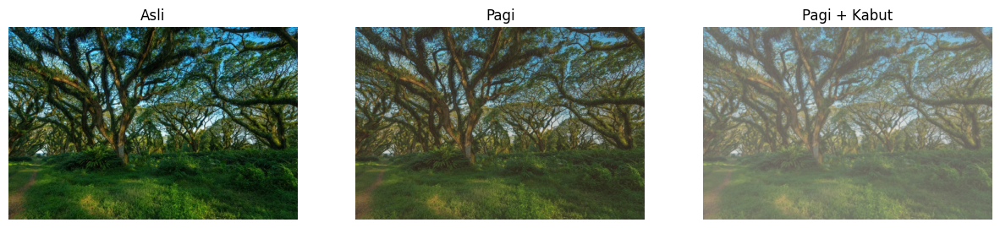

In [ ]:
# Filter Suasana pagi dan Kabut
# =============================

# Step 1: Kurangi kontras & cerahkan
# =============================
alpha = 0.9  # contrast
beta = 20    # brightness
soft = cv.convertScaleAbs(img, alpha=alpha, beta=beta)

# =============================
# Step 2: Tambahkan warm tone (kemerahan / oranye)
# =============================
warm_tint = np.full_like(soft, (40, 70, 120))  # BGR
pagi = cv.addWeighted(soft, 0.8, warm_tint, 0.2, 0)

# =============================
# Step 3: Tambahkan haze (kabut tipis) dengan filter2D
# =============================
# Kernel blur Gaussian-like untuk menciptakan efek kabut
kernel = cv.getGaussianKernel(3, 3)
kernel = kernel @ kernel.T  # jadikan 2D kernel
kabut = cv.filter2D(pagi, -1, kernel)

# tambah layer putih untuk kabut lebih nyata
white_layer = np.full_like(pagi, 255)
kabut = cv.addWeighted(kabut, 0.7, white_layer, 0.3, 0)

show_side_by_side(
    [img, pagi, kabut],
    ["Asli", "Pagi", "Pagi + Kabut"]
)

## **Tugas Praktikum**

**1. Tugas Analisis: Perbandingan Mean Filter (Blur Biasa) vs. Median Filter pada Noise “Salt and
Pepper”**

**a. Tambahkan noise bintik hitam-putih (Salt and Pepper) ke sebuah citra keabuan (grayscale).**

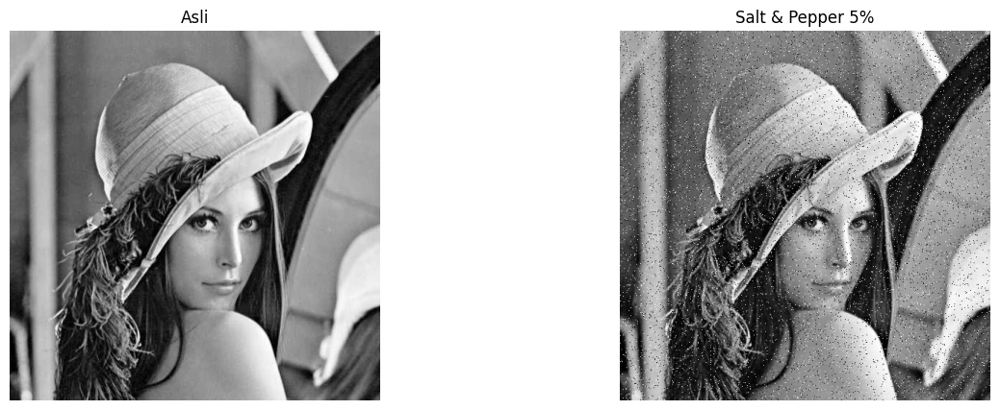

In [81]:
lena_gray = cv.imread(BASE + '/lena.jpg.jpeg', cv.IMREAD_GRAYSCALE)

def salt_pepper(img, amount=0.05, seed=42):
    rng = np.random.default_rng(seed)
    out = img.copy()
    r = rng.random(img.shape)
    out[r < amount / 2] = 0
    out[r > 1 - amount / 2] = 255
    return out

noisy = salt_pepper(lena_gray, 0.05)

show_side_by_side([lena_gray, noisy], ['Asli', 'Salt & Pepper 5%'])

**b. Terapkan Mean Filter(3 x 3) dan Median Filter (3 x 3).**

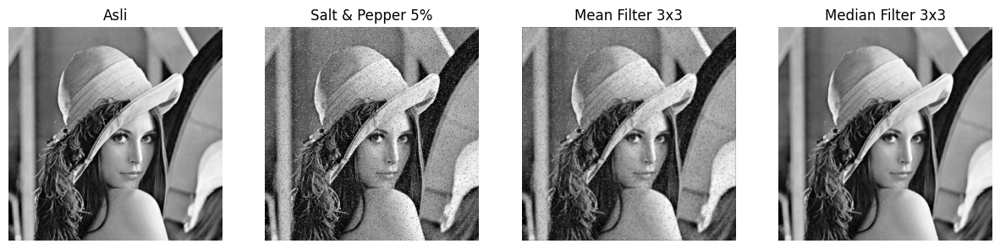

Citra                       MSE    PSNR (dB)
Noisy                   1014.86        18.07
Mean 3x3                 182.26        25.52
Median 3x3                31.91        33.09


In [82]:
def median_filter(img, k=3):
    p = k // 2
    fp = np.pad(img, p, mode='edge')
    H, W = img.shape
    tumpukan = [fp[i:i+H, j:j+W] for i in range(k) for j in range(k)]
    return np.median(np.stack(tumpukan), axis=0).astype(np.uint8)

def mse(a, b):
    return np.mean((a.astype(np.float64) - b.astype(np.float64)) ** 2)

def psnr(a, b):
    return 10 * np.log10(255**2 / mse(a, b))

mean3 = convolution2d(noisy, np.ones((3,3), dtype=np.float32) / 9, 1, 1)
median3 = median_filter(noisy, 3)

show_side_by_side([lena_gray, noisy, mean3, median3],
                   ['Asli', 'Salt & Pepper 5%', 'Mean Filter 3x3', 'Median Filter 3x3'])

print(f"{'Citra':20s} {'MSE':>10s} {'PSNR (dB)':>12s}")
for nama, im in [('Noisy', noisy), ('Mean 3x3', mean3), ('Median 3x3', median3)]:
    print(f'{nama:20s} {mse(lena_gray, im):10.2f} {psnr(lena_gray, im):12.2f}')

**c. Amati dan analisis secara visual mengapa Median Filter jauh lebih bersih dalam menghapus noise tersebut dibanding Mean Filter.**

**Jawaban:**

Median Filter terbukti jauh lebih efektif dalam menghilangkan noise salt-and-pepper dibandingkan Mean Filter, karena perbedaan mendasar pada cara kerja kedua metode tersebut. Mean Filter bekerja dengan menghitung nilai rata-rata dari seluruh piksel tetangga, sehingga nilai ekstrem (0 atau 255) yang berasal dari noise tetap ikut memengaruhi hasil perhitungan. Akibatnya, noise tidak benar-benar hilang, melainkan hanya tersebar menjadi efek blur pada citra. Sebaliknya, Median Filter mengambil nilai tengah dari piksel-piksel tetangga yang telah diurutkan. Oleh karena noise salt-and-pepper merupakan nilai ekstrem atau outlier, nilai tersebut hampir selalu tersingkir dari posisi median, sehingga noise dapat dihilangkan secara efektif tanpa menyebabkan citra menjadi buram.

**2. Tugas Evaluasi: Pemilihan Ukuran Kernel terbaik untuk Menajamkan Citra (Sharpening)**

**a. Buat kernel penajaman (Sharpening Kernel) ukuran 3 x 3 dan 5 x 5.**

In [83]:
kernel_3x3 = np.array([[0,-1,0],
                        [-1,5,-1],
                        [0,-1,0]], dtype=np.float32)

kernel_5x5 = np.array([[0, 0,-1, 0, 0],
                        [0,-1,-2,-1, 0],
                        [-1,-2,17,-2,-1],
                        [0,-1,-2,-1, 0],
                        [0, 0,-1, 0, 0]], dtype=np.float32)

print('Jumlah kernel 3x3 =', kernel_3x3.sum())
print('Jumlah kernel 5x5 =', kernel_5x5.sum())

Jumlah kernel 3x3 = 1.0
Jumlah kernel 5x5 = 1.0


**b. Terapkan pada citra yang sedikit buram (blurry).**

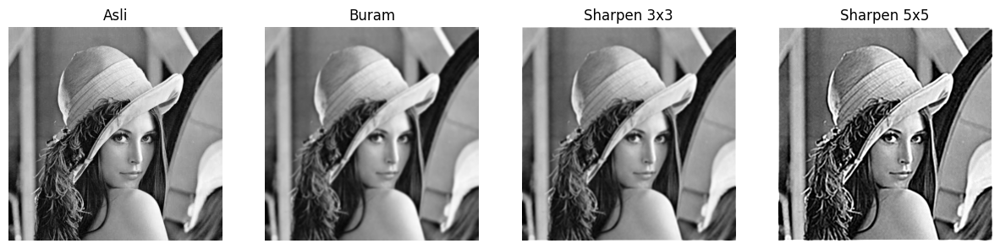

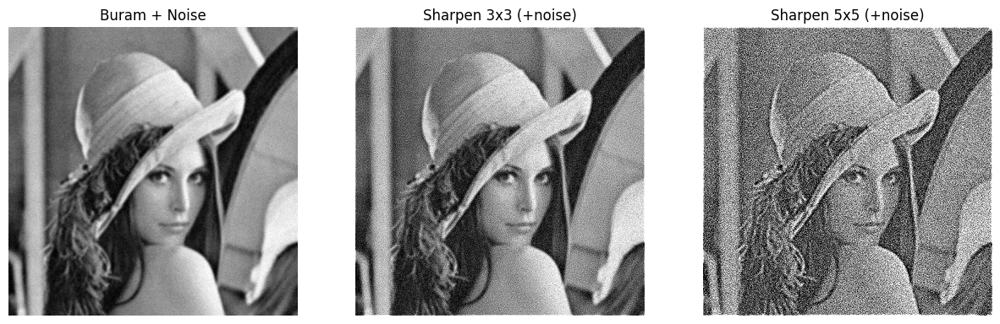

In [84]:
blurry = cv.GaussianBlur(gray, (7,7), 2)

noise = np.random.normal(0, 10, gray.shape)
blurry_noisy = np.clip(blurry.astype(np.float32) + noise, 0, 255).astype(np.uint8)

sharp_3x3 = convolution2d(blurry, kernel_3x3, 1, 1)
sharp_5x5 = convolution2d(blurry, kernel_5x5, 1, 2)

sharp_3x3_noisy = convolution2d(blurry_noisy, kernel_3x3, 1, 1)
sharp_5x5_noisy = convolution2d(blurry_noisy, kernel_5x5, 1, 2)

show_side_by_side([gray, blurry, sharp_3x3, sharp_5x5],
                   ['Asli', 'Buram', 'Sharpen 3x3', 'Sharpen 5x5'])

show_side_by_side([blurry_noisy, sharp_3x3_noisy, sharp_5x5_noisy],
                   ['Buram + Noise', 'Sharpen 3x3 (+noise)', 'Sharpen 5x5 (+noise)'])

**c. Evaluasi hasilnya berdasarkan aspek Kejelasan Tepi vs. Kadar Noise/Noise Distortion yang
dihasilkan. Tentukan kernel mana yang paling optimal untuk digunakan sehari-hari.**

**Jawaban:**

Pada citra buram tanpa noise, kedua kernel sama-sama meningkatkan kejelasan tepi. Kernel 3×3 menghasilkan penajaman yang halus dan terkendali, sedangkan kernel 5×5 memberikan penajaman lebih kuat dengan tepi lebih tegas, namun mulai menampakkan sedikit distorsi (artefak bintik, overshoot di sekitar tepi).

Perbedaan terlihat jauh lebih jelas saat diuji pada citra buram yang sudah mengandung noise: kernel 3×3 tetap relatif terkendali, sedangkan kernel 5×5 justru ikut memperkuat noise yang ada, menghasilkan citra yang jauh lebih "berisik" dan kotor dibanding kernel 3×3. Ini karena kernel 5×5 melibatkan lebih banyak piksel tetangga dalam perhitungan, sehingga lebih sensitif terhadap variasi kecil (termasuk noise) di sekitar tiap piksel.

Untuk pemakaian sehari-hari, kernel 3×3 lebih optimal karena menyeimbangkan kejelasan tepi dengan minimnya distorsi, terutama pada citra yang kemungkinan sudah mengandung noise alami (misalnya dari kamera). Kernel 5×5 hanya disarankan untuk citra yang benar-benar bersih dan sangat buram, yang membutuhkan penajaman agresif.

**3. Tugas Kreasi: Filter Kartun Sederhana**

**a. Buatlah sebuah fungsi kustom bernama kartun(image) yang menggabungkan:**
* Penghalusan warna menggunakan **Bilateral Filter** agar area warna menjadi rata.
* Deteksi garis tepi menggunakan **Adaptive Thresholding** atau **Canny Edge**.
* Penggabungan (kombinasi) keduanya menggunakan operasi logika/perkalian piksel.

In [75]:
def kartun(image, metode='adaptive', n_bilateral=5, gabung='and'):
    # Penghalusan warna dengan Bilateral Filter
    warna = image.copy()

    for _ in range(n_bilateral):
        warna = cv.bilateralFilter(
            warna,
            d=9,
            sigmaColor=75,
            sigmaSpace=75
        )

    # Ubah ke grayscale dan haluskan
    g = cv.medianBlur(
        cv.cvtColor(image, cv.COLOR_BGR2GRAY),
        7
    )

    # Deteksi tepi
    if metode == 'adaptive':
        tepi = cv.adaptiveThreshold(
            g,
            255,
            cv.ADAPTIVE_THRESH_MEAN_C,
            cv.THRESH_BINARY,
            9,
            8
        )

    elif metode == 'canny':
        e = cv.Canny(g, 80, 160)
        e = cv.dilate(e, np.ones((2, 2), np.uint8))
        tepi = cv.bitwise_not(e)

    else:
        raise ValueError("metode: 'adaptive' atau 'canny'")

    # Ubah tepi grayscale menjadi 3 channel
    tepi3 = cv.cvtColor(tepi, cv.COLOR_GRAY2BGR)

    # Gabungkan warna dan tepi
    if gabung == 'and':
        return cv.bitwise_and(warna, tepi3)

    return (
        warna.astype(np.float32) *
        (tepi3.astype(np.float32) / 255.0)
    ).astype(np.uint8)


**b. Tampilkan hasil citra asli dengan citra efek kartun bersebelahan.**

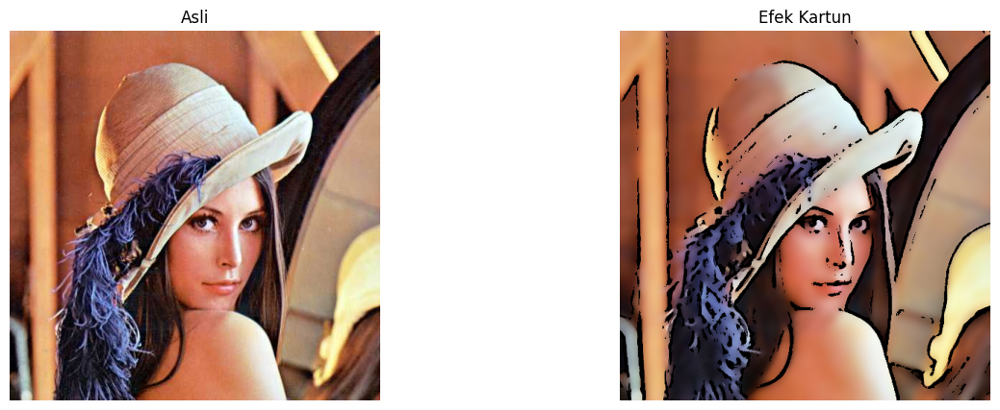

In [85]:
img_test = cv.imread(BASE + '/lena.jpg.jpeg')
hasil_kartun = kartun(img_test)

show_side_by_side([img_test, hasil_kartun], ['Asli', 'Efek Kartun'])